In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def perceptron_train(X, y, learning_rate=0.1, epochs=10, gate_name="Gate"):

    # Add bias term
    X_bias = np.c_[np.ones(len(X)), X]

    # Initialize weights
    weights = np.zeros(X_bias.shape[1])

    update_number = 0

    print("\n" + "=" * 60)
    print(f"{gate_name} GATE")
    print("=" * 60)

    for epoch in range(epochs):

        print(f"\nEpoch {epoch + 1}")

        error_count = 0

        for i in range(len(X)):

            # Calculate weighted sum
            z = np.dot(X_bias[i], weights)

            # Step activation function
            prediction = 1 if z >= 0 else 0

            # Calculate error
            error = y[i] - prediction

            # Update weights
            if error != 0:

                weights = weights + learning_rate * error * X_bias[i]

                update_number += 1
                error_count += 1

                print(f"\nUpdate {update_number}")
                print(f"Input      : {X[i]}")
                print(f"Target     : {y[i]}")
                print(f"Prediction : {prediction}")
                print(f"Error      : {error}")
                print(f"Weights    : {weights}")

                # Plot decision boundary
                plot_decision_boundary(
                    X, y, weights,
                    gate_name, update_number
                )

        # If no errors, training is complete
        if error_count == 0:
            print("\nTraining converged!")
            break

    print("\nFinal Weights:", weights)

    return weights

In [12]:
def plot_decision_boundary(X, y, weights, gate_name, update_number):

    plt.figure(figsize=(7, 6))

    # Plot output 0
    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        marker='o',
        s=150,
        label='Output 0'
    )

    # Plot output 1
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        marker='s',
        s=150,
        label='Output 1'
    )

    # Decision boundary:
    # w0 + w1*x1 + w2*x2 = 0

    if weights[2] != 0:

        x1 = np.linspace(-0.5, 1.5, 100)

        x2 = -(weights[0] + weights[1] * x1) / weights[2]

        plt.plot(
            x1,
            x2,
            linewidth=2,
            label='Decision Boundary'
        )

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)

    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.title(
        f"{gate_name} Gate - Weight Update {update_number}"
    )

    plt.grid(True)
    plt.legend()

    plt.show()

In [13]:
# OR gate inputs
X_OR = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# OR gate outputs
y_OR = np.array([
    0,
    1,
    1,
    1
])

print("OR Gate Truth Table")
print("-------------------")

for x, y in zip(X_OR, y_OR):
    print(f"{x[0]} OR {x[1]} = {y}")

OR Gate Truth Table
-------------------
0 OR 0 = 0
0 OR 1 = 1
1 OR 0 = 1
1 OR 1 = 1



OR GATE

Epoch 1

Update 1
Input      : [0 0]
Target     : 0
Prediction : 1
Error      : -1
Weights    : [-0.1  0.   0. ]


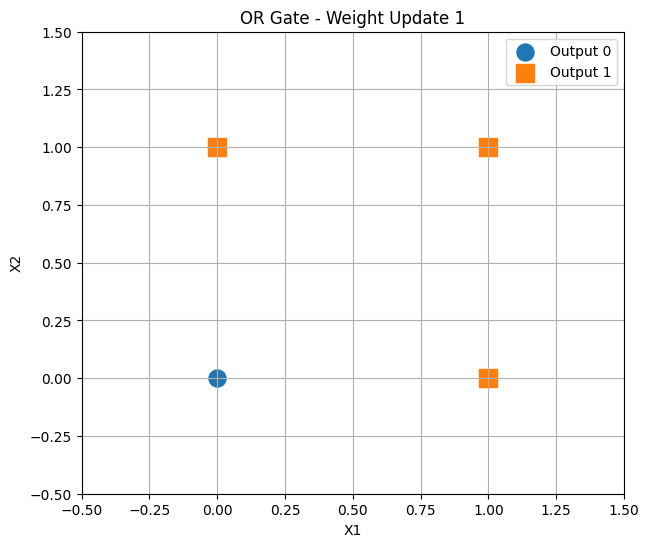


Update 2
Input      : [0 1]
Target     : 1
Prediction : 0
Error      : 1
Weights    : [0.  0.  0.1]


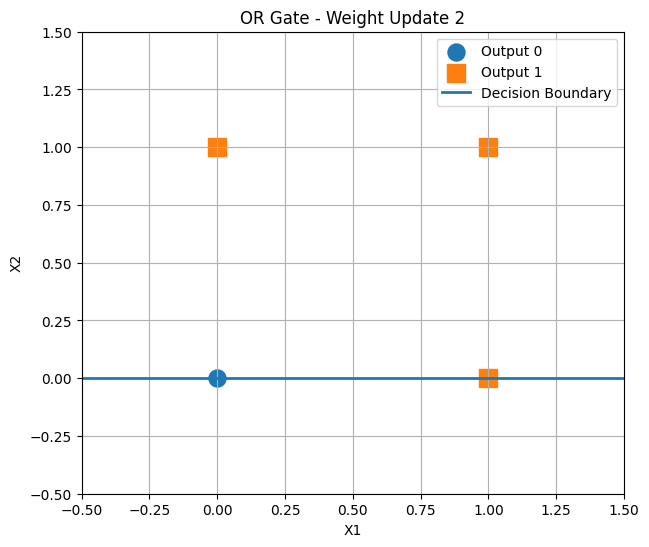


Epoch 2

Update 3
Input      : [0 0]
Target     : 0
Prediction : 1
Error      : -1
Weights    : [-0.1  0.   0.1]


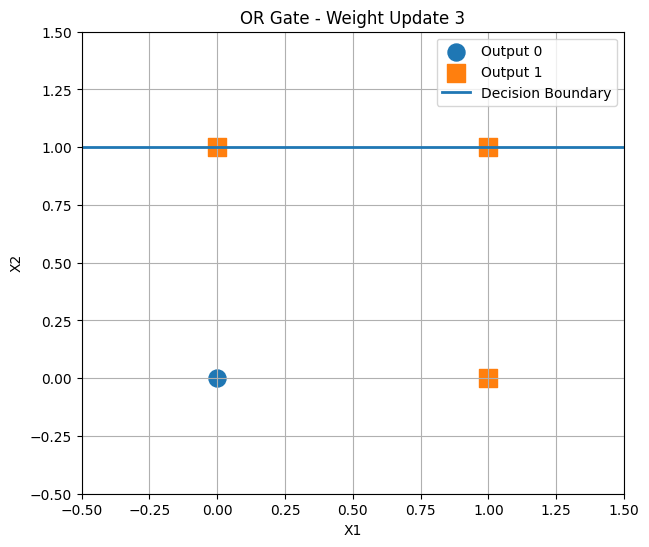


Update 4
Input      : [1 0]
Target     : 1
Prediction : 0
Error      : 1
Weights    : [0.  0.1 0.1]


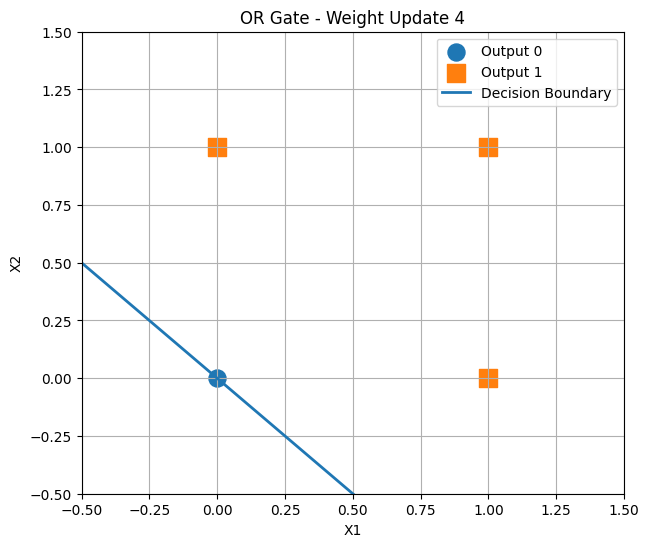


Epoch 3

Update 5
Input      : [0 0]
Target     : 0
Prediction : 1
Error      : -1
Weights    : [-0.1  0.1  0.1]


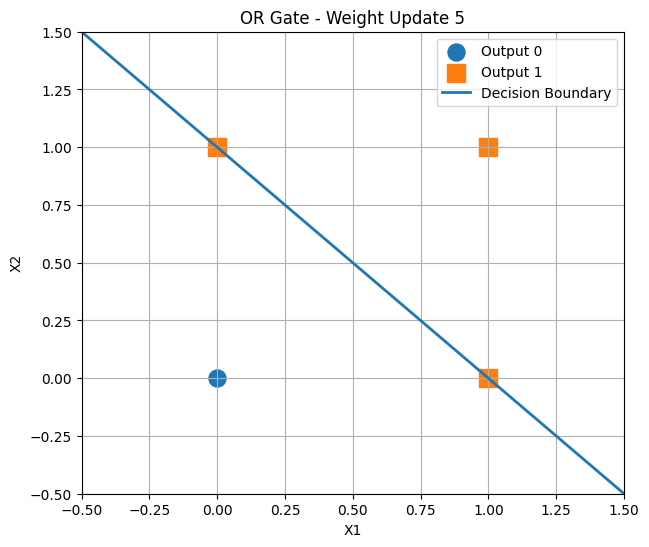


Epoch 4

Training converged!

Final Weights: [-0.1  0.1  0.1]


In [14]:
weights_OR = perceptron_train(
    X_OR,
    y_OR,
    learning_rate=0.1,
    epochs=10,
    gate_name="OR"
)

In [15]:
# AND gate inputs
X_AND = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# AND gate outputs
y_AND = np.array([
    0,
    0,
    0,
    1
])

print("AND Gate Truth Table")
print("--------------------")

for x, y in zip(X_AND, y_AND):
    print(f"{x[0]} AND {x[1]} = {y}")

AND Gate Truth Table
--------------------
0 AND 0 = 0
0 AND 1 = 0
1 AND 0 = 0
1 AND 1 = 1



AND GATE

Epoch 1

Update 1
Input      : [0 0]
Target     : 0
Prediction : 1
Error      : -1
Weights    : [-0.1  0.   0. ]


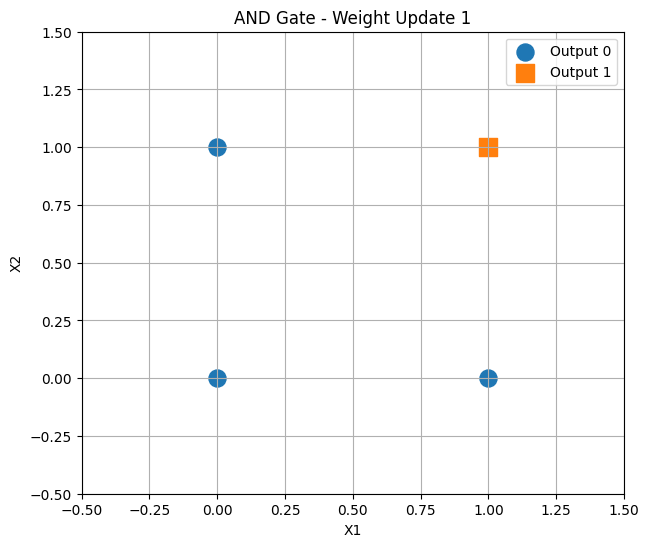


Update 2
Input      : [1 1]
Target     : 1
Prediction : 0
Error      : 1
Weights    : [0.  0.1 0.1]


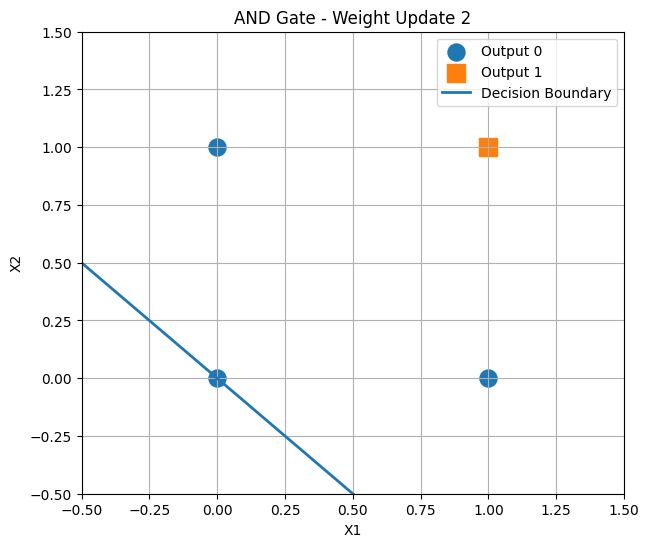


Epoch 2

Update 3
Input      : [0 0]
Target     : 0
Prediction : 1
Error      : -1
Weights    : [-0.1  0.1  0.1]


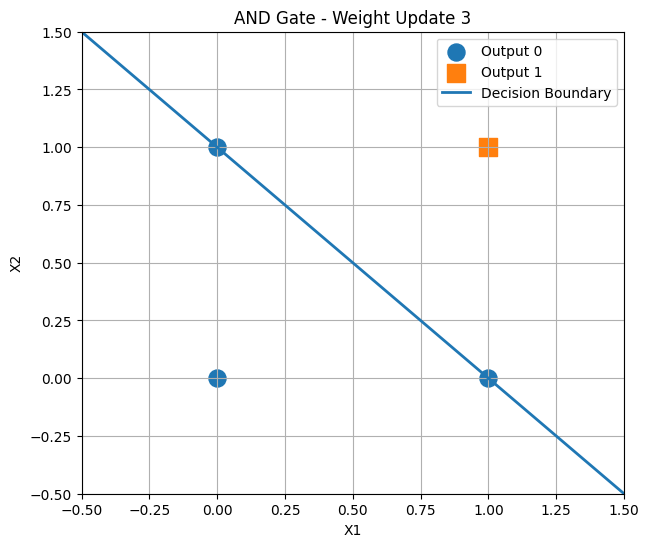


Update 4
Input      : [0 1]
Target     : 0
Prediction : 1
Error      : -1
Weights    : [-0.2  0.1  0. ]


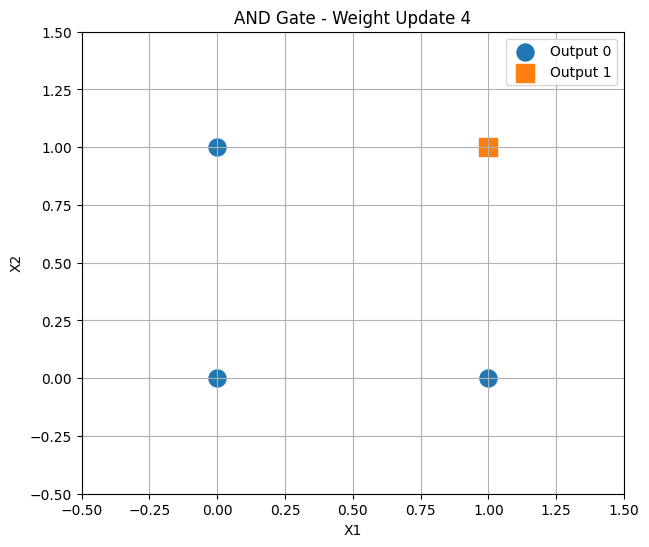


Update 5
Input      : [1 1]
Target     : 1
Prediction : 0
Error      : 1
Weights    : [-0.1  0.2  0.1]


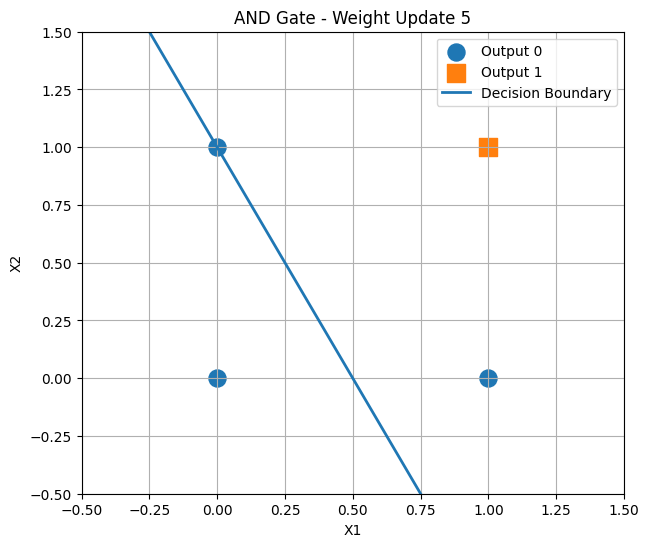


Epoch 3

Update 6
Input      : [0 1]
Target     : 0
Prediction : 1
Error      : -1
Weights    : [-0.2  0.2  0. ]


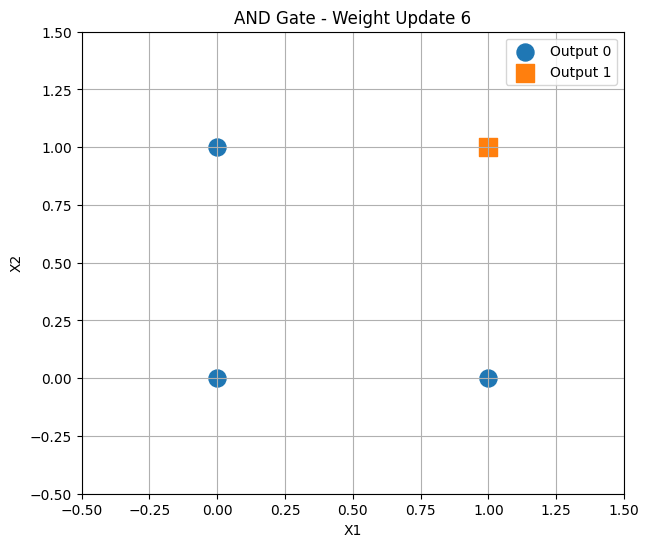


Update 7
Input      : [1 0]
Target     : 0
Prediction : 1
Error      : -1
Weights    : [-0.3  0.1  0. ]


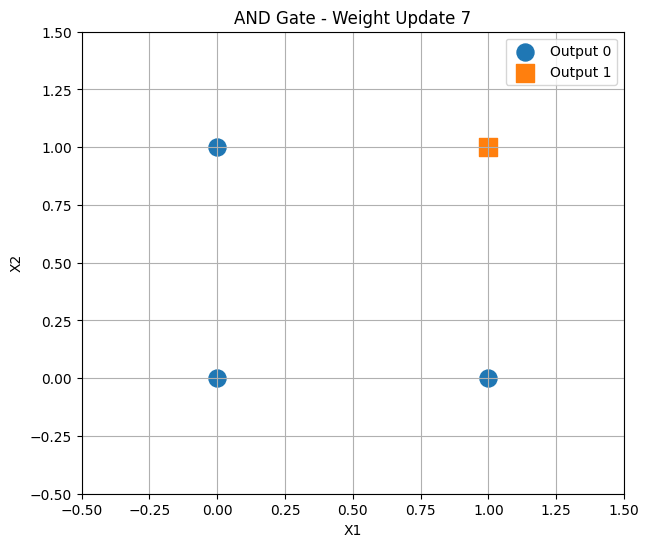


Update 8
Input      : [1 1]
Target     : 1
Prediction : 0
Error      : 1
Weights    : [-0.2  0.2  0.1]


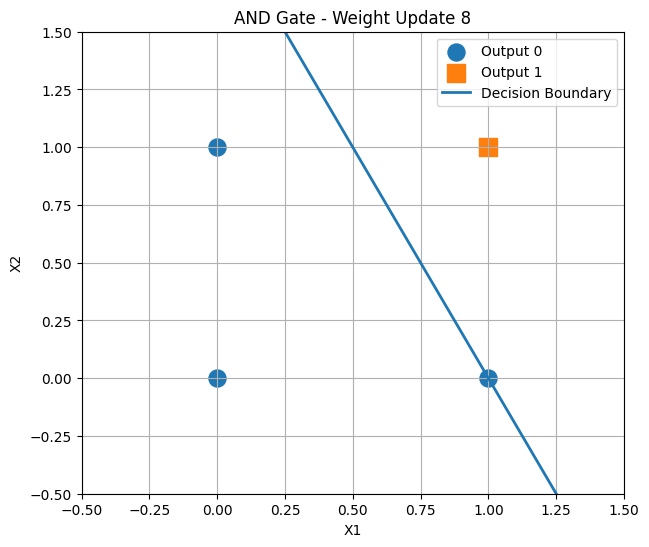


Epoch 4

Training converged!

Final Weights: [-0.2  0.2  0.1]


In [16]:
weights_AND = perceptron_train(
    X_AND,
    y_AND,
    learning_rate=0.1,
    epochs=10,
    gate_name="AND"
)

In [17]:
# NOT gate
# Second column is a dummy feature used only for 2D plotting

X_NOT = np.array([
    [0, 0],
    [1, 0]
])

y_NOT = np.array([
    1,
    0
])

print("NOT Gate Truth Table")
print("--------------------")

for x, y in zip(X_NOT, y_NOT):
    print(f"NOT {x[0]} = {y}")

NOT Gate Truth Table
--------------------
NOT 0 = 1
NOT 1 = 0



NOT GATE

Epoch 1

Update 1
Input      : [1 0]
Target     : 0
Prediction : 1
Error      : -1
Weights    : [-0.1 -0.1  0. ]


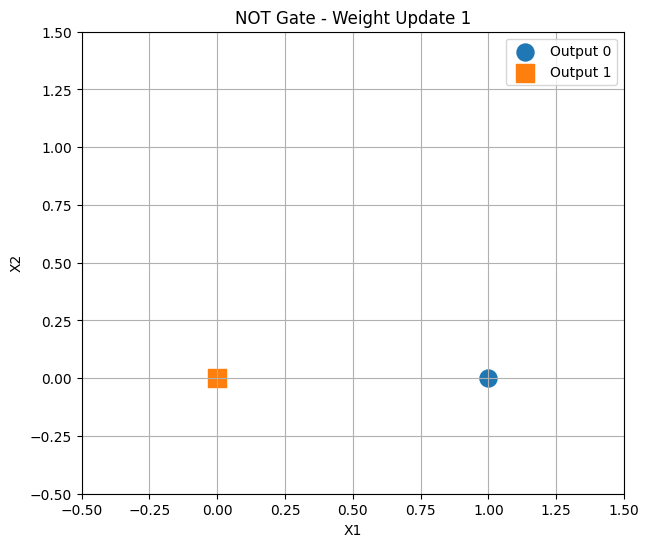


Epoch 2

Update 2
Input      : [0 0]
Target     : 1
Prediction : 0
Error      : 1
Weights    : [ 0.  -0.1  0. ]


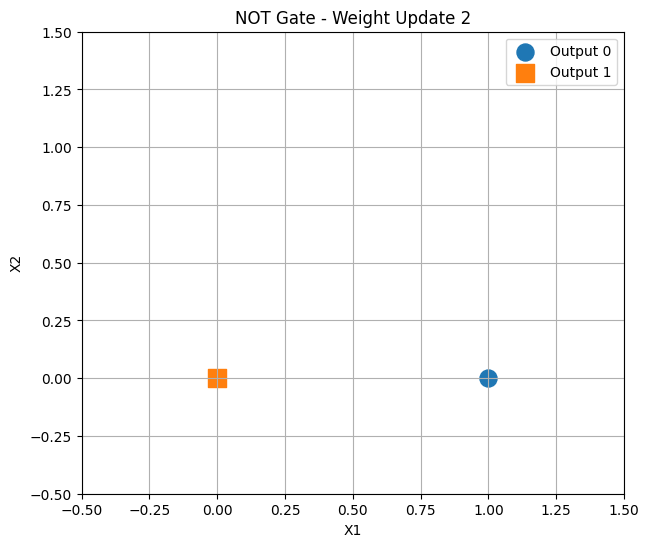


Epoch 3

Training converged!

Final Weights: [ 0.  -0.1  0. ]


In [18]:
weights_NOT = perceptron_train(
    X_NOT,
    y_NOT,
    learning_rate=0.1,
    epochs=10,
    gate_name="NOT"
)

In [19]:
print("\n" + "=" * 50)
print("FINAL WEIGHTS")
print("=" * 50)

print("OR  Gate :", weights_OR)
print("AND Gate :", weights_AND)
print("NOT Gate :", weights_NOT)


FINAL WEIGHTS
OR  Gate : [-0.1  0.1  0.1]
AND Gate : [-0.2  0.2  0.1]
NOT Gate : [ 0.  -0.1  0. ]


In [20]:
def predict(X, weights):

    X_bias = np.c_[np.ones(len(X)), X]

    predictions = []

    for x in X_bias:
        z = np.dot(x, weights)
        prediction = 1 if z >= 0 else 0
        predictions.append(prediction)

    return np.array(predictions)


print("=" * 50)
print("PREDICTIONS")
print("=" * 50)

print("\nOR Gate")
print("Actual    :", y_OR)
print("Predicted :", predict(X_OR, weights_OR))

print("\nAND Gate")
print("Actual    :", y_AND)
print("Predicted :", predict(X_AND, weights_AND))

print("\nNOT Gate")
print("Actual    :", y_NOT)
print("Predicted :", predict(X_NOT, weights_NOT))

PREDICTIONS

OR Gate
Actual    : [0 1 1 1]
Predicted : [0 1 1 1]

AND Gate
Actual    : [0 0 0 1]
Predicted : [0 0 0 1]

NOT Gate
Actual    : [1 0]
Predicted : [1 0]
